In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
x=pd.read_csv("breast_cancer_data.csv")
x.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


In [2]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [3]:
x.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [4]:
x.drop(columns=["Unnamed: 32"],inplace=True)

In [5]:
x.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

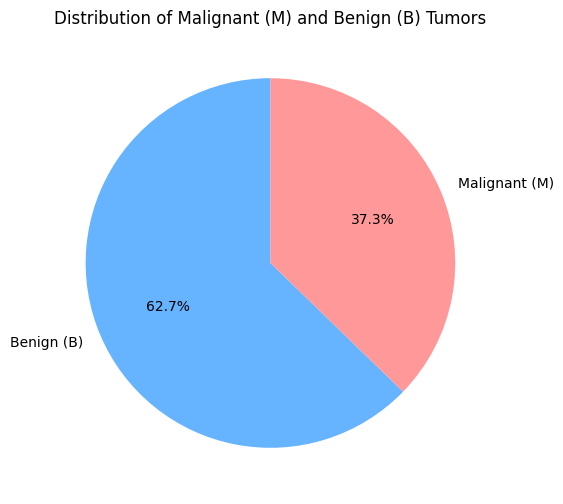

In [6]:
plt.figure(figsize=(6,6))
x['diagnosis'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    startangle=90, 
    labels=['Benign (B)', 'Malignant (M)'], 
    colors=['#66b3ff','#ff9999']
)
plt.title('Distribution of Malignant (M) and Benign (B) Tumors')
plt.ylabel('')
plt.show()

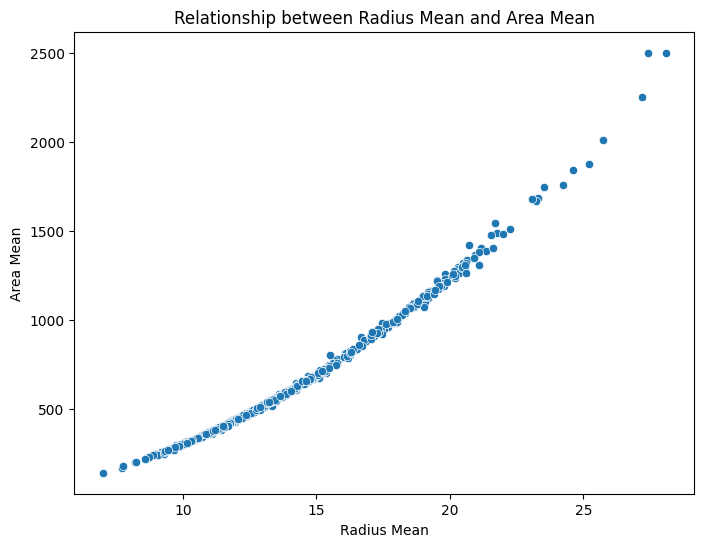

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=x, x='radius_mean', y='area_mean')
plt.title('Relationship between Radius Mean and Area Mean')
plt.xlabel('Radius Mean')
plt.ylabel('Area Mean')
plt.show()

Based on the plot, it appears there's a strong positive correlation between these two features. As radius_mean increases, area_mean also tends to increase. This makes sense intuitively, as a larger radius would generally lead to a larger area

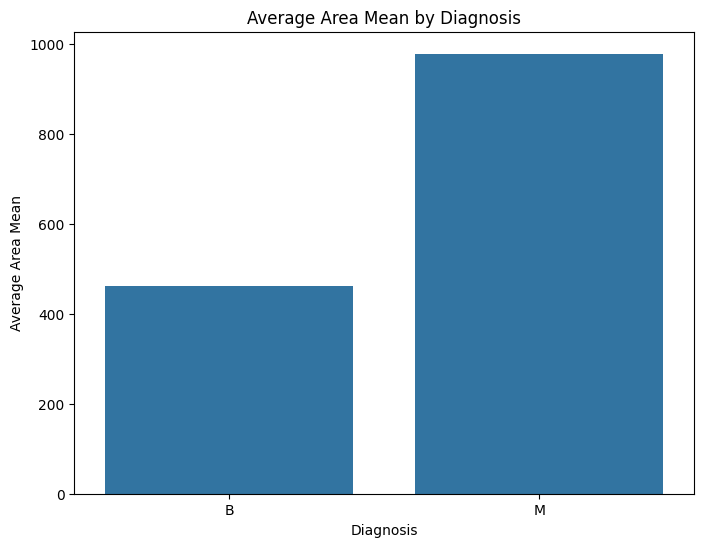

In [8]:
avg_area_by_diagnosis = x.groupby('diagnosis')['area_mean'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=avg_area_by_diagnosis, x='diagnosis', y='area_mean')
plt.title('Average Area Mean by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Average Area Mean')
plt.show()

This suggests that there is a notable difference in the average cell area between benign and malignant tumors in this dataset, with malignant tumors tending to have a larger average area. This kind of visual exploration is helpful in understanding the potential relationships between features and the target variable (diagnosis in this case)

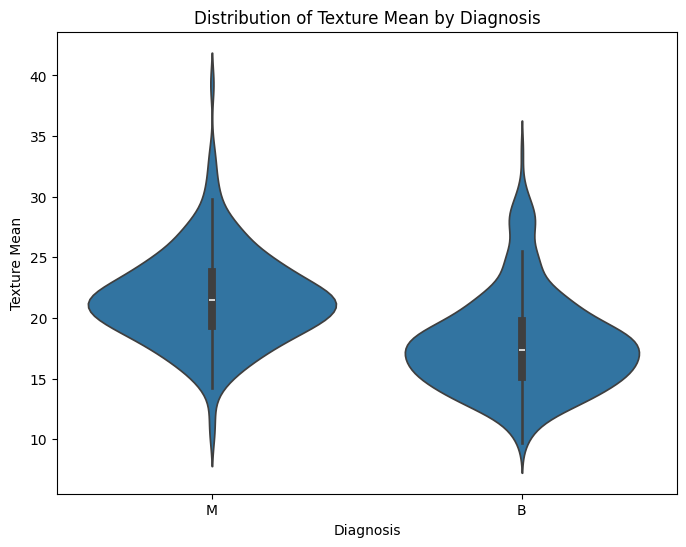

In [9]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=x, x='diagnosis', y='texture_mean')
plt.title('Distribution of Texture Mean by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Texture Mean')
plt.show()

The violin plot shows the distribution of texture mean values for both benign (B) and malignant (M) diagnoses. You can see that the distribution of texture_mean for malignant tumors appears to be slightly wider and shifted towards higher values compared to benign tumors. This suggests that malignant tumors may have a greater variability in texture and potentially higher average texture values

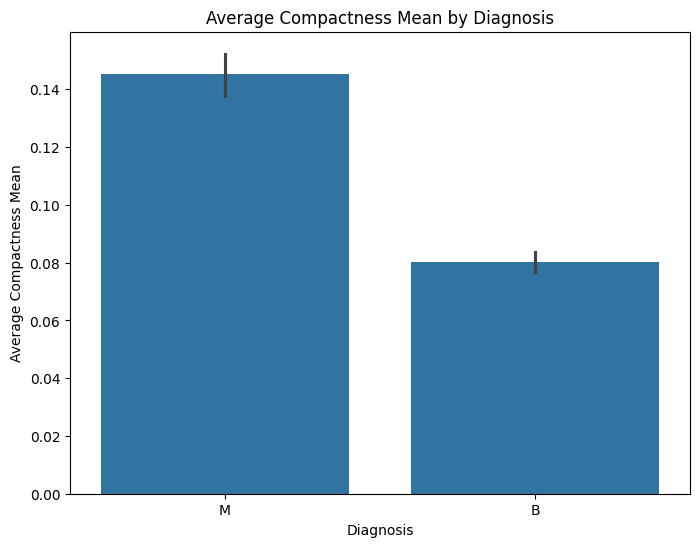

In [10]:
plt.figure(figsize=(8,6))
sns.barplot(data=x, x='diagnosis', y='compactness_mean')
plt.title('Average Compactness Mean by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Average Compactness Mean')
plt.show()

The height of each bar indicates the average value of compactness_mean for that diagnosis group. From the plot, it appears that the average compactness_mean is higher for malignant tumors compared to benign tumors. This suggests that malignant tumors tend to be more compact on average

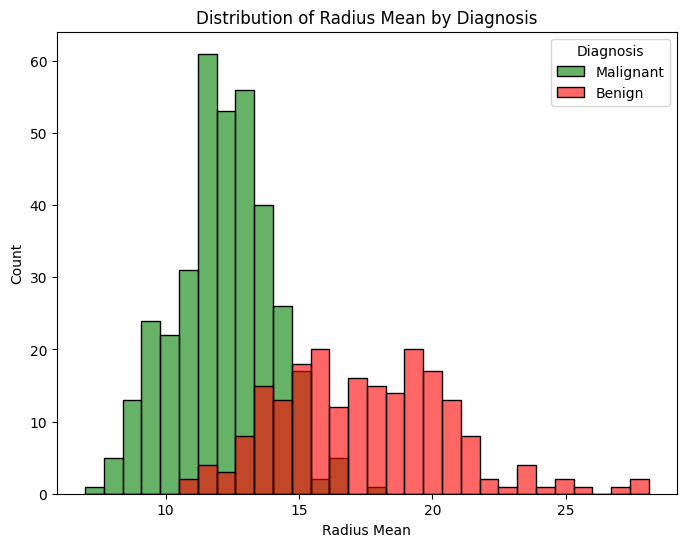

In [11]:
plt.figure(figsize=(8,6))
sns.histplot(data=x, x='radius_mean', hue='diagnosis', bins=30, palette={'M': 'red', 'B': 'green'}, alpha=0.6)
plt.title('Distribution of Radius Mean by Diagnosis')
plt.xlabel('Radius Mean')
plt.ylabel('Count')
plt.legend(title='Diagnosis', labels=['Malignant', 'Benign'])
plt.show()

you can observe how the distribution of radius_mean differs between benign and malignant tumors. It appears that malignant tumors tend to have larger radius_mean values, with their distribution shifted towards the right compared to benign tumors. Benign tumors seem to be more concentrated at smaller radius_mean values.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X = x.drop('diagnosis', axis=1)
y = x['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='M')
recall = recall_score(y_test, y_pred, pos_label='M')
f1 = f1_score(y_test, y_pred, pos_label='M')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

Accuracy: 0.9649
Precision: 0.9756
Recall: 0.9302
F1-score: 0.9524


In [13]:
from sklearn.tree import DecisionTreeClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, pos_label='M')
recall_dt = recall_score(y_test, y_pred_dt, pos_label='M')
f1_dt = f1_score(y_test, y_pred_dt, pos_label='M')

print(f'Accuracy: {accuracy_dt:.4f}')
print(f'Precision: {precision_dt:.4f}')
print(f'Recall: {recall_dt:.4f}')
print(f'F1-score: {f1_dt:.4f}')

Accuracy: 0.9386
Precision: 0.9091
Recall: 0.9302
F1-score: 0.9195


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
nn_model = MLPClassifier(random_state=42)
nn_model.fit(X_train_scaled, y_train)
y_pred_nn = nn_model.predict(X_test_scaled)
accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn, pos_label='M')
recall_nn = recall_score(y_test, y_pred_nn, pos_label='M')
f1_nn = f1_score(y_test, y_pred_nn, pos_label='M')

print(f'Neural Network Accuracy: {accuracy_nn:.4f}')
print(f'Neural Network Precision: {precision_nn:.4f}')
print(f'Neural Network Recall: {recall_nn:.4f}')
print(f'Neural Network F1-score: {f1_nn:.4f}')

Neural Network Accuracy: 0.9737
Neural Network Precision: 0.9762
Neural Network Recall: 0.9535
Neural Network F1-score: 0.9647


c:\Users\night\.conda\envs\myenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [15]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, pos_label='M')
recall_svm = recall_score(y_test, y_pred_svm, pos_label='M')
f1_svm = f1_score(y_test, y_pred_svm, pos_label='M')

print(f'SVM Accuracy: {accuracy_svm:.4f}')
print(f'SVM Precision: {precision_svm:.4f}')
print(f'SVM Recall: {recall_svm:.4f}')
print(f'SVM F1-score: {f1_svm:.4f}')

SVM Accuracy: 0.9825
SVM Precision: 1.0000
SVM Recall: 0.9535
SVM F1-score: 0.9762


In [16]:
performance_summary = {
    'Random Forest': {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-score': f1},
    'Decision Tree': {'Accuracy': accuracy_dt, 'Precision': precision_dt, 'Recall': recall_dt, 'F1-score': f1_dt},
    'Neural Network': {'Accuracy': accuracy_nn, 'Precision': precision_nn, 'Recall': recall_nn, 'F1-score': f1_nn},
    'SVM': {'Accuracy': accuracy_svm, 'Precision': precision_svm, 'Recall': recall_svm, 'F1-score': f1_svm}
}

display(pd.DataFrame(performance_summary).T)
best_accuracy_model = max(performance_summary, key=lambda model: performance_summary[model]['Accuracy'])
best_f1_model = max(performance_summary, key=lambda model: performance_summary[model]['F1-score'])

print(f"The model with the best accuracy is: {best_accuracy_model} (Accuracy: {performance_summary[best_accuracy_model]['Accuracy']:.4f})")
print(f"The model with the best F1-score is: {best_f1_model} (F1-score: {performance_summary[best_f1_model]['F1-score']:.4f})")

,Accuracy,Precision,Recall,F1-score
Random Forest,0.964912,0.975610,0.930233,0.952381
Decision Tree,0.938596,0.909091,0.930233,0.919540
Neural Network,0.973684,0.976190,0.953488,0.964706
SVM,0.982456,1.000000,0.953488,0.976190


The model with the best accuracy is: SVM (Accuracy: 0.9825)
The model with the best F1-score is: SVM (F1-score: 0.9762)


In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
import pickle

# Load dataset
data = load_breast_cancer()
X = data.data   # 30 features
y = data.target # labels

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build pipeline (scaler + SVM)
pipeline = make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True))

# Train
pipeline.fit(X_train, y_train)

# Save model
with open("SVM.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("✅ Model trained and saved as SVM.pkl")


✅ Model trained and saved as SVM.pkl


In [17]:
import pickle

with open("SVM.pkl", "wb") as f:
    pickle.dump(svm_model, f)

print("✅ Best model (SVM) saved as svm_model.pkl")


✅ Best model (SVM) saved as svm_model.pkl
